# 01 — Rol 1: Incertidumbre e Información
**Proyecto Retador: Patrones Invisibles** - ML No Supervisado - Universidad de La Sabana - 2026-II

**Pregunta de UrbanMove:** ¿qué tan predecible es la demanda según zona, hora y tipo de día, y cuánto vale planear la flota con esa información?

Todo se mide en bits (logaritmo en base 2). Un bit es la información de una pregunta de sí/no con dos respuestas igual de probables. Con 20 zonas, la incertidumbre máxima posible es $\log_2 20 = 4.32$ bits: ese es el caso en que un pedido puede salir de cualquier zona con la misma probabilidad.

| Sección | Concepto | Pregunta de negocio |
|---|---|---|
| 1 | Probabilidad | ¿Dónde y cuándo se concentra la demanda? |
| 2 | Entropía de Shannon | ¿En qué franja es más predecible dónde habrá pedidos? |
| 3 | Entropía condicional | Si conozco la hora o el origen, ¿cuánta incertidumbre queda sobre el destino? |
| 4 | Información mutua | ¿Vale la pena planear la flota por hora? |
| 5 | Divergencia KL | ¿Qué tan distinto es el fin de semana del día laboral? ¿Qué horas se alejan del promedio? |
| 6 | Entropía cruzada | ¿Cuánto cuesta planear el fin de semana con el patrón del día laboral? |
| 7 | Desigualdad de Jensen | ¿Por qué KL, información mutua y entropía tienen los límites que tienen? |
| 8 | Log-sum-exp | ¿Cómo combinar probabilidades de cientos de viajes sin que el computador las redondee a cero? |

Datos de entrada: `muestra_50k.csv`, generada en `00_datos.ipynb` (50 000 viajes, 20 zonas comunes).

## 0. Configuración y funciones base

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)
RUTA_DATOS = '../data'

muestra = pd.read_csv(f'{RUTA_DATOS}/muestra_50k.csv', parse_dates=['pickup_datetime', 'dropoff_datetime'])
ORDEN_FRANJAS = ['madrugada', 'pico_am', 'valle', 'pico_pm', 'noche']
muestra['franja'] = pd.Categorical(muestra.franja, categories=ORDEN_FRANJAS, ordered=True)
muestra['fecha'] = muestra.pickup_datetime.dt.normalize()

K = 20                       # número de zonas
N = len(muestra)
H_MAX = np.log2(K)           # entropía máxima posible con K zonas
print(f'{N:,} viajes | {K} zonas | entropía máxima = log2({K}) = {H_MAX:.4f} bits')

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 110

50,000 viajes | 20 zonas | entropía máxima = log2(20) = 4.3219 bits


Las funciones se escriben a mano para que cada fórmula sea visible:

- **Entropía:** $H(X) = -\sum_x p(x)\log_2 p(x)$. Por convención $0 \log 0 = 0$, así que las categorías con probabilidad cero se omiten.
- **Divergencia KL:** $D_{KL}(P\|Q) = \sum_x p(x)\log_2 \frac{p(x)}{q(x)}$.
- **Entropía cruzada:** $H(P,Q) = -\sum_x p(x)\log_2 q(x)$.
- **Información mutua** desde una tabla de conteos: $I(X;Y) = \sum_{x,y} p(x,y)\log_2\frac{p(x,y)}{p(x)p(y)}$.

In [2]:
def entropia(p):
    """Entropía de Shannon en bits de una distribución (arreglo que suma 1)."""
    p = np.asarray(p, float)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def kl(p, q):
    """Divergencia KL D(P||Q) en bits. Requiere q > 0 donde p > 0."""
    p, q = np.asarray(p, float), np.asarray(q, float)
    m = p > 0
    return np.sum(p[m] * np.log2(p[m] / q[m]))

def entropia_cruzada(p, q):
    """Entropía cruzada H(P,Q) en bits."""
    p, q = np.asarray(p, float), np.asarray(q, float)
    m = p > 0
    return -np.sum(p[m] * np.log2(q[m]))

def distribucion(serie, categorias, alfa=0.0):
    """Probabilidades de cada categoría. alfa > 0 aplica suavizado de Laplace:
    se suma alfa a cada conteo para que ninguna categoría quede con probabilidad 0."""
    conteos = serie.value_counts().reindex(categorias, fill_value=0).values + alfa
    return conteos / conteos.sum()

def informacion_mutua(x, y):
    """I(X;Y) en bits a partir de dos columnas de enteros (plug-in)."""
    x, y = np.asarray(x), np.asarray(y)
    nx, ny = x.max() + 1, y.max() + 1
    conj = np.bincount(x * ny + y, minlength=nx * ny).reshape(nx, ny) / len(x)
    px, py = conj.sum(1, keepdims=True), conj.sum(0, keepdims=True)
    m = conj > 0
    return np.sum(conj[m] * np.log2(conj[m] / (px @ py)[m]))

ZONAS = list(range(K))

## 1. Probabilidad: dónde y cuándo se concentra la demanda

La demanda se modela como una variable aleatoria discreta: la zona de recogida $Z$ de un viaje elegido al azar. Su distribución $P(Z)$ se estima con frecuencias relativas. Condicionar en la franja, $P(Z \mid \text{franja})$, muestra cómo cambia el mapa de demanda a lo largo del día.

In [3]:
p_zona = distribucion(muestra.zona_origen, ZONAS)
p_hora = distribucion(muestra.hora, range(24))

tabla_prob = pd.DataFrame({'P(zona)': p_zona}, index=pd.Index(ZONAS, name='zona'))
tabla_prob['P acumulada'] = tabla_prob['P(zona)'].cumsum()
print(f'Las 5 zonas con más demanda concentran el {100*tabla_prob["P acumulada"].iloc[4]:.1f} % de las recogidas.')
print(f'Hora con más demanda: {p_hora.argmax()}:00 ({100*p_hora.max():.2f} %) | '
      f'hora con menos: {p_hora.argmin()}:00 ({100*p_hora.min():.2f} %)')
tabla_prob.T

Las 5 zonas con más demanda concentran el 45.2 % de las recogidas.
Hora con más demanda: 19:00 (6.35 %) | hora con menos: 4:00 (1.05 %)


zona,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
P(zona),0.0972,0.0959,0.0928,0.0839,0.0821,0.0717,0.0687,0.0666,0.0602,0.0531,0.0488,0.0445,0.0405,0.0259,0.0216,0.0187,0.0104,0.0076,0.0065,0.0033
P acumulada,0.0972,0.1931,0.2859,0.3698,0.4519,0.5236,0.5923,0.6589,0.7191,0.7722,0.8210,0.8655,0.9060,0.9319,0.9535,0.9722,0.9826,0.9902,0.9967,1.0000


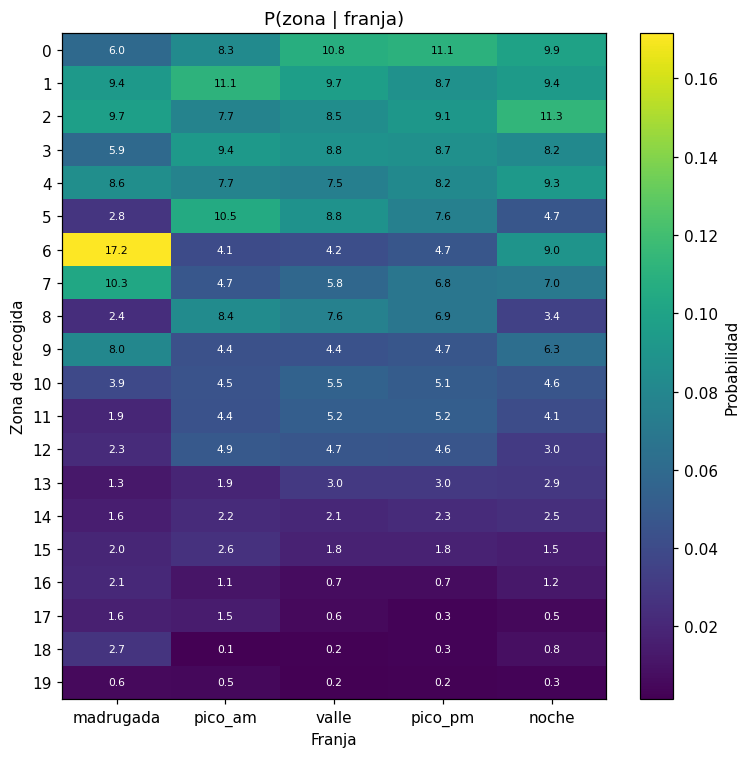

In [4]:
# P(zona | franja): cada columna suma 1
p_zona_franja = pd.crosstab(muestra.zona_origen, muestra.franja, normalize='columns')

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(p_zona_franja.values, cmap='viridis', aspect='auto')
ax.set(xticks=range(5), xticklabels=ORDEN_FRANJAS, yticks=range(K),
       xlabel='Franja', ylabel='Zona de recogida', title='P(zona | franja)')
for i in range(K):
    for j in range(5):
        v = p_zona_franja.values[i, j]
        ax.text(j, i, f'{100*v:.1f}', ha='center', va='center', fontsize=7,
                color='white' if v < 0.06 else 'black')
plt.colorbar(im, label='Probabilidad'); plt.tight_layout(); plt.show()

**Lectura:** La demanda está anclada en Manhattan: las 5 zonas principales (0 a 4, Midtown y alrededores) concentran el 45.2 % de las recogidas y las 13 zonas de Manhattan (0 a 12) el 90.6 %. Los aeropuertos pesan poco en volumen: LaGuardia (zona 13) el 2.6 % y JFK (zona 14) el 2.2 %. En el tiempo, la hora de más demanda (19:00, 6.35 %) tiene 6 veces más viajes que la de menos (4:00, 1.05 %). El mapa de calor muestra que el reparto espacial es estable durante el día, pero en la madrugada cambia: la zona 6 pasa de ~4 % de las recogidas en el día a 17.2 %.

## 2. Entropía de Shannon: qué tan predecible es la demanda

$$H(Z) = -\sum_{z=1}^{K} P(z)\log_2 P(z)$$

La entropía es el número promedio de preguntas de sí/no que se necesitan para adivinar la zona de un pedido. Tiene dos lecturas útiles para operaciones:

- **Entropía normalizada** $H/\log_2 K$: 0 % significa que toda la demanda sale de una sola zona y 100 % que se reparte igual entre las 20.
- **Número efectivo de zonas** $2^{H}$: la demanda se comporta como si estuviera repartida por igual entre $2^H$ zonas. Es la cantidad de zonas que realmente hay que cubrir.

In [5]:
H_global = entropia(p_zona)
print(f'H(zona) global = {H_global:.4f} bits  |  normalizada = {100*H_global/H_MAX:.1f} %  |  '
      f'zonas efectivas = {2**H_global:.2f} de {K}')

H(zona) global = 3.9924 bits  |  normalizada = 92.4 %  |  zonas efectivas = 15.92 de 20


### 2.1 Entropía por franja con intervalos de confianza

Para responder qué tan seguro es cada valor se usa bootstrap: se remuestrean los viajes de cada franja con reemplazo 1 000 veces y se recalcula la entropía. Remuestrear $n$ viajes con reemplazo equivale a sortear los conteos de una multinomial con las probabilidades observadas, que es lo que hace rng.multinomial (mucho más rápido). El intervalo del 95 % son los percentiles 2.5 y 97.5.

In [6]:
B = 1000
filas = []
for f in ORDEN_FRANJAS:
    z = muestra.loc[muestra.franja == f, 'zona_origen']
    p = distribucion(z, ZONAS)
    boot = [entropia(c / len(z)) for c in rng.multinomial(len(z), p, size=B)]
    H = entropia(p)
    filas.append({'franja': f, 'viajes': len(z), 'H (bits)': H,
                  'IC95 inf': np.percentile(boot, 2.5), 'IC95 sup': np.percentile(boot, 97.5),
                  'H normalizada (%)': 100 * H / H_MAX, 'zonas efectivas': 2**H})
entropia_franja = pd.DataFrame(filas).set_index('franja')
entropia_franja

,viajes,H (bits),IC95 inf,IC95 sup,H normalizada (%),zonas efectivas
franja,,,,,,
madrugada,5916,3.8689,3.8384,3.8939,89.5171,14.6098
pico_am,7567,3.9678,3.9464,3.9841,91.8065,15.6470
valle,14465,3.9440,3.9302,3.9549,91.2551,15.3906
pico_pm,11029,3.9495,3.9336,3.9616,91.3821,15.4493
noche,11023,3.9445,3.9268,3.9582,91.2661,15.3957


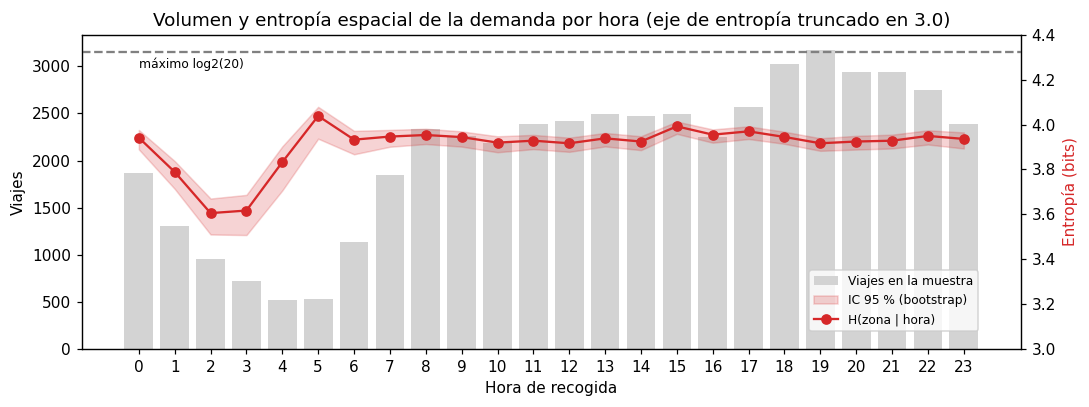

Madrugada: H de la franja = 3.869 bits | promedio de sus horas = 3.813 bits | diferencia = I(hora; zona | madrugada) = 0.056 bits


In [7]:
# Entropía hora por hora con intervalo bootstrap del 95 %
H_hora, ic_inf, ic_sup, n_hora = [], [], [], []
for h in range(24):
    z = muestra.loc[muestra.hora == h, 'zona_origen']
    p = distribucion(z, ZONAS)
    boot = [entropia(c / len(z)) for c in rng.multinomial(len(z), p, size=B)]
    H_hora.append(entropia(p)); n_hora.append(len(z))
    ic_inf.append(np.percentile(boot, 2.5)); ic_sup.append(np.percentile(boot, 97.5))
H_hora = np.array(H_hora)

fig, ax1 = plt.subplots(figsize=(10, 3.8))
ax1.bar(range(24), n_hora, color='lightgray', label='Viajes en la muestra')
ax1.set(xlabel='Hora de recogida', ylabel='Viajes', xticks=range(24))
ax2 = ax1.twinx()
ax2.fill_between(range(24), ic_inf, ic_sup, color='C3', alpha=0.2, label='IC 95 % (bootstrap)')
ax2.plot(range(24), H_hora, 'o-', color='C3', label='H(zona | hora)')
ax2.axhline(H_MAX, ls='--', color='gray'); ax2.text(0, H_MAX - 0.07, 'máximo log2(20)', fontsize=8)
ax2.set_ylabel('Entropía (bits)', color='C3'); ax2.set_ylim(3.0, 4.4)
ax1.set_title('Volumen y entropía espacial de la demanda por hora (eje de entropía truncado en 3.0)')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.18), fontsize=8); plt.tight_layout(); plt.show()

# Entropía de la franja completa vs. promedio ponderado de sus horas (efecto de mezclar)
mad = muestra[muestra.franja == 'madrugada']
H_pool = entropia(distribucion(mad.zona_origen, ZONAS))
H_prom = sum(len(g) / len(mad) * entropia(distribucion(g.zona_origen, ZONAS)) for _, g in mad.groupby('hora'))
print(f'Madrugada: H de la franja = {H_pool:.3f} bits | promedio de sus horas = {H_prom:.3f} bits | '
      f'diferencia = I(hora; zona | madrugada) = {H_pool - H_prom:.3f} bits')

Lectura. La entropía global es 3.99 bits, el 92.4 % del máximo: la demanda se comporta como si estuviera repartida por igual entre 15.9 de las 20 zonas. No hay un puñado de zonas que concentre los pedidos.

Hora a hora, el único cambio significativo es la concentración entre la 1:00 y las 3:00. A las 2:00 y 3:00 la entropía cae a 3.61 bits (unas 12 zonas efectivas, IC95 ≈ 3.50–3.69), por debajo de cualquier hora entre las 6:00 y las 23:00. La zona 6 concentra el 23.6 % de las recogidas en ese momento. El sesgo por el menor número de viajes a esa hora es de ~0.02 bits y no explica la caída. Las 4:00 son una transición, y de las 5:00 a las 23:00 las diferencias entre horas caen dentro de los intervalos de confianza.

La franja madrugada completa (3.87 bits) es más dispersa que el promedio de sus horas (3.81 bits), porque junta las 2:00–3:00, muy concentradas, con las 5:00, que ya tienen patrón diurno. Mezclar distribuciones distintas aumenta la entropía.

Implicación: entre la 1:00 y las 3:00 conviene concentrar los pocos conductores activos alrededor de la zona 6. El resto del día la flota debe repartirse en proporción a P(zona | hora), no en pocas zonas. A las 5:00 la demanda es baja y dispersa, el momento más difícil de cubrir.

## 3. Entropía condicional: cuánta incertidumbre queda sobre el destino

$$H(D \mid X) = \sum_{x} P(x)\, H(D \mid X = x)$$

Es la entropía del destino $D$ que queda, en promedio, cuando ya se conoce $X$. Se compara con $H(D)$ sin información adicional. Tres variables candidatas para "conocer antes": la franja, la hora exacta y la zona de origen.

In [8]:
def entropia_condicional(y, x, categorias_y):
    """H(Y|X) = sum_x P(x) H(Y|X=x) en bits."""
    total = 0.0
    for valor, grupo in pd.Series(y).groupby(pd.Series(x).values):
        total += len(grupo) / len(y) * entropia(distribucion(grupo, categorias_y))
    return total

H_dest = entropia(distribucion(muestra.zona_destino, ZONAS))
condicionales = pd.DataFrame({
    'H(destino | X) bits': {
        'Sin información': H_dest,
        'X = franja': entropia_condicional(muestra.zona_destino, muestra.franja.astype(str), ZONAS),
        'X = hora': entropia_condicional(muestra.zona_destino, muestra.hora, ZONAS),
        'X = zona de origen': entropia_condicional(muestra.zona_destino, muestra.zona_origen, ZONAS),
    }})
condicionales['reducción vs. sin información (%)'] = 100 * (1 - condicionales.iloc[:, 0] / H_dest)
condicionales

,H(destino | X) bits,reducción vs. sin información (%)
Sin información,4.1299,0.0000
X = franja,4.0752,1.3259
X = hora,4.0582,1.7356
X = zona de origen,3.7530,9.1257


**Lectura:** El destino es más incierto que el origen (4.13 frente a 3.99 bits): los viajes nacen en Manhattan pero terminan más dispersos. Conocer la hora solo reduce esa incertidumbre un 1.7 % (la franja, un 1.3 %). Conocer la zona de origen la reduce un 9.1 %, más de cinco veces más.

**Implicación:** para anticipar dónde quedará libre un conductor (el destino de su viaje actual es su próximo punto de partida), la zona de origen vale mucho más que la hora.

## 4. Información mutua: cuánto vale cada variable para planear

$$I(X;Y) = H(Y) - H(Y \mid X) = \sum_{x,y} p(x,y)\log_2\frac{p(x,y)}{p(x)\,p(y)}$$

Es la reducción de incertidumbre sobre $Y$ al conocer $X$ (y es simétrica: lo mismo vale al revés). Si $X$ e $Y$ son independientes, $p(x,y) = p(x)p(y)$ y la información mutua es 0.

In [9]:
pares = {
    'hora ; zona origen':   ('hora', 'zona_origen'),
    'hora ; zona destino':  ('hora', 'zona_destino'),
    'fin de semana ; zona origen': ('fin_de_semana', 'zona_origen'),
    'zona origen ; zona destino': ('zona_origen', 'zona_destino'),
}
im_tabla = pd.DataFrame({'I (bits)': {k: informacion_mutua(muestra[a], muestra[b]) for k, (a, b) in pares.items()}})
im_tabla['% de H(Y) explicado'] = 100 * im_tabla['I (bits)'] / [
    H_global, H_dest, H_global, H_dest]

# Verificación de la identidad I = H(D) - H(D|hora)
print(f"I(hora; destino) directa        = {im_tabla.loc['hora ; zona destino', 'I (bits)']:.5f} bits")
print(f"H(destino) - H(destino | hora)  = {H_dest - condicionales.loc['X = hora'].iloc[0]:.5f} bits")
im_tabla

I(hora; destino) directa        = 0.07168 bits
H(destino) - H(destino | hora)  = 0.07168 bits


,I (bits),% de H(Y) explicado
hora ; zona origen,0.0678,1.6972
hora ; zona destino,0.0717,1.7356
fin de semana ; zona origen,0.0099,0.2490
zona origen ; zona destino,0.3769,9.1257


### 4.1 ¿Es real o es ruido? Prueba de permutación

El estimador de información mutua a partir de frecuencias **siempre da un valor mayor que cero**, aunque las variables sean independientes: con muestras finitas, la tabla de frecuencias nunca sale exactamente igual a $p(x)p(y)$. Para saber si el valor observado es real, se barajan al azar las horas (lo que destruye cualquier relación con la zona) 500 veces y se calcula la información mutua de cada barajado. Eso da la distribución de la información mutua "por puro azar".

Como referencia teórica, el sesgo esperado bajo independencia es aproximadamente $\frac{(|X|-1)(|Y|-1)}{2N\ln 2}$ bits (corrección de Miller–Madow).

I(hora; destino) observada     = 0.07168 bits
Media bajo independencia        = 0.00633 bits  (máximo en 500 barajados: 0.00764)
Sesgo teórico de Miller-Madow   = 0.00630 bits
Información mutua corregida     = 0.06535 bits
Valor p                         < 0.0020
La observada es 11.3 veces la esperada por azar.


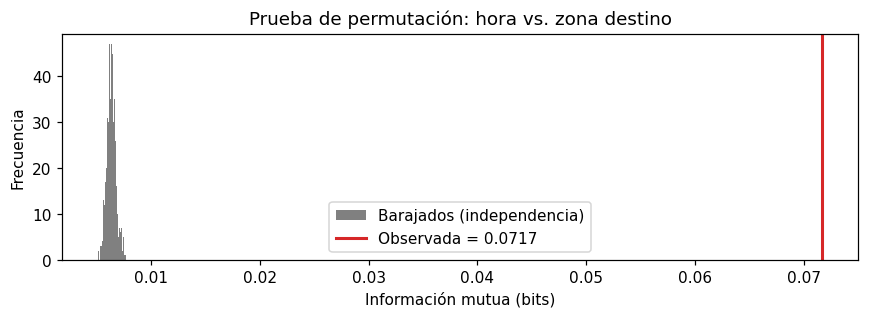

In [10]:
def prueba_permutacion(x, y, n_perm=500):
    obs = informacion_mutua(x, y)
    nulas = np.array([informacion_mutua(rng.permutation(x), y) for _ in range(n_perm)])
    p_valor = (np.sum(nulas >= obs) + 1) / (n_perm + 1)
    return obs, nulas, p_valor

obs, nulas, p_val = prueba_permutacion(muestra.hora.values, muestra.zona_destino.values)
sesgo_teorico = (24 - 1) * (K - 1) / (2 * N * np.log(2))

print(f'I(hora; destino) observada     = {obs:.5f} bits')
print(f'Media bajo independencia        = {nulas.mean():.5f} bits  (máximo en 500 barajados: {nulas.max():.5f})')
print(f'Sesgo teórico de Miller-Madow   = {sesgo_teorico:.5f} bits')
print(f'Información mutua corregida     = {obs - nulas.mean():.5f} bits')
print(f'Valor p                         < {p_val:.4f}')
print(f'La observada es {obs / nulas.mean():.1f} veces la esperada por azar.')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(nulas, bins=30, color='gray', label='Barajados (independencia)')
ax.axvline(obs, color='C3', lw=2, label=f'Observada = {obs:.4f}')
ax.set(xlabel='Información mutua (bits)', ylabel='Frecuencia', title='Prueba de permutación: hora vs. zona destino')
ax.legend(); plt.tight_layout(); plt.show()

**Lectura:** La relación hora–destino es real pero pequeña: 0.0717 bits observados frente a 0.0063 bits esperados por azar (el sesgo de Miller–Madow predice 0.0063, casi idéntico a la simulación). Es 11.3 veces el valor de azar, ninguno de los 500 barajados la alcanzó (p < 0.002) y la información mutua corregida es 0.065 bits.

En comparación, el origen aporta 0.377 bits sobre el destino, más de cinco veces lo que aporta la hora. Y saber si es fin de semana apenas dice algo sobre la zona de origen (0.0099 bits, 0.25 % de su entropía).

**Implicación:** planear por hora está estadísticamente justificado, pero la matriz origen–destino es la información más valiosa para el despacho.

## 5. Divergencia KL: qué tan distintos son dos contextos

$$D_{KL}(P\|Q) = \sum_x P(x)\log_2\frac{P(x)}{Q(x)}$$

Mide cuántos bits extra por viaje se pierden al describir datos que siguen $P$ usando el modelo $Q$. Vale 0 solo si $P = Q$ y no es simétrica: $D_{KL}(P\|Q) \neq D_{KL}(Q\|P)$ en general.

**Suavizado de Laplace:** Si alguna categoría tiene probabilidad 0 en $Q$ pero no en $P$, el cociente $P/Q$ es infinito y la KL explota. Para evitarlo se suma 1 a cada conteo antes de normalizar ($\alpha = 1$).

Se comparan fin de semana y día laboral en dos dimensiones: dónde se piden viajes (20 zonas) y cuándo (24 horas).

In [11]:
laboral = muestra[muestra.fin_de_semana == 0]
finde = muestra[muestra.fin_de_semana == 1]
ALFA = 1

comparaciones = {}
for nombre, col, cats in [('zona de origen', 'zona_origen', ZONAS), ('hora del día', 'hora', range(24))]:
    P = distribucion(finde[col], cats, ALFA)      # fin de semana
    Q = distribucion(laboral[col], cats, ALFA)    # día laboral
    comparaciones[nombre] = {'KL(finde || laboral)': kl(P, Q), 'KL(laboral || finde)': kl(Q, P),
                             'H(finde)': entropia(P), 'H(laboral)': entropia(Q)}
kl_tabla = pd.DataFrame(comparaciones).T
kl_tabla

,KL(finde || laboral),KL(laboral || finde),H(finde),H(laboral)
zona de origen,0.0501,0.0465,4.0139,3.9708
hora del día,0.1884,0.1628,4.4772,4.4091


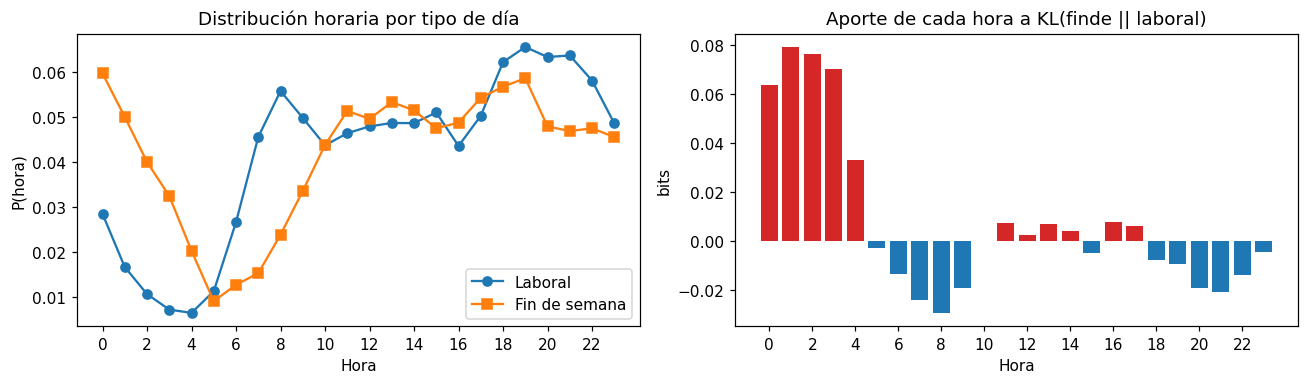

Horas que más aportan a la divergencia: 1:00 (0.079 bits), 2:00 (0.076 bits), 3:00 (0.070 bits), 0:00 (0.064 bits)


In [12]:
# Distribución horaria de ambos contextos: explica por qué la KL temporal es grande
P_h = distribucion(finde.hora, range(24), ALFA)
Q_h = distribucion(laboral.hora, range(24), ALFA)
contrib = P_h * np.log2(P_h / Q_h)       # aporte de cada hora a KL(finde || laboral)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(range(24), Q_h, 'o-', label='Laboral'); axes[0].plot(range(24), P_h, 's-', label='Fin de semana')
axes[0].set(xlabel='Hora', ylabel='P(hora)', title='Distribución horaria por tipo de día', xticks=range(0, 24, 2))
axes[0].legend()
axes[1].bar(range(24), contrib, color=np.where(contrib > 0, 'C3', 'C0'))
axes[1].set(xlabel='Hora', ylabel='bits', title='Aporte de cada hora a KL(finde || laboral)', xticks=range(0, 24, 2))
plt.tight_layout(); plt.show()
top = pd.Series(contrib, index=range(24)).sort_values(ascending=False).head(4)
print('Horas que más aportan a la divergencia:', ', '.join(f'{h}:00 ({v:.3f} bits)' for h, v in top.items()))

### 5.1 ¿Qué horas se alejan del mapa promedio de demanda?

Una política que posiciona la flota según el mapa **promedio** del día, $P(Z)$, pierde $D_{KL}(P(Z\mid h)\,\|\,P(Z))$ bits por viaje en cada hora $h$. Las horas con KL alta son las horas en que el promedio falla.

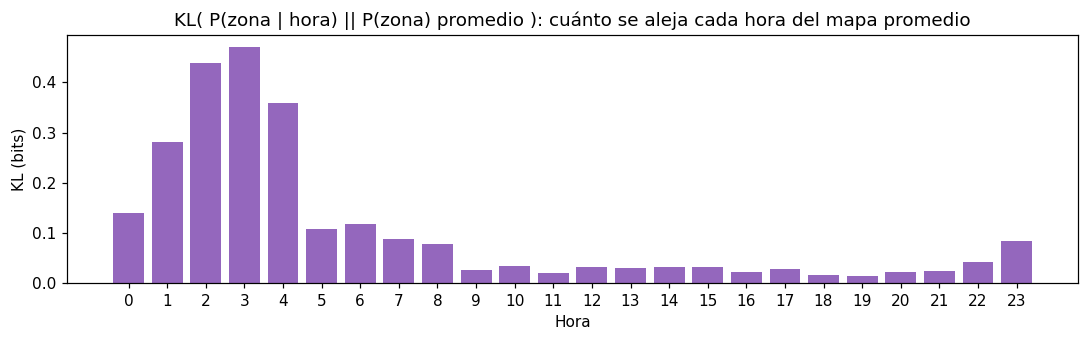

Horas más distintas del promedio: 3:00 (0.471), 2:00 (0.439), 4:00 (0.360), 1:00 (0.282)
Horas más parecidas al promedio: 11:00 (0.021), 18:00 (0.016), 19:00 (0.015)


In [13]:
p_zona_suav = distribucion(muestra.zona_origen, ZONAS, ALFA)
kl_hora = np.array([kl(distribucion(muestra.loc[muestra.hora == h, 'zona_origen'], ZONAS, ALFA), p_zona_suav)
                    for h in range(24)])

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(range(24), kl_hora, color='C4')
ax.set(xlabel='Hora', ylabel='KL (bits)', xticks=range(24),
       title='KL( P(zona | hora) || P(zona) promedio ): cuánto se aleja cada hora del mapa promedio')
plt.tight_layout(); plt.show()
orden_kl = pd.Series(kl_hora, index=range(24)).sort_values(ascending=False)
print('Horas más distintas del promedio:', ', '.join(f'{h}:00 ({v:.3f})' for h, v in orden_kl.head(4).items()))
print('Horas más parecidas al promedio:', ', '.join(f'{h}:00 ({v:.3f})' for h, v in orden_kl.tail(3).items()))

In [14]:
# Cuáles zonas cambian más a las horas con mayor KL (qué hay detrás del número)
h_top = orden_kl.index[0]
p_h_top = distribucion(muestra.loc[muestra.hora == h_top, 'zona_origen'], ZONAS, ALFA)
cambio = pd.DataFrame({'P(zona) promedio': p_zona_suav, f'P(zona | {h_top}:00)': p_h_top,
                       'razón': p_h_top / p_zona_suav}, index=pd.Index(ZONAS, name='zona'))
cambio.sort_values('razón', ascending=False).head(6)

,P(zona) promedio,P(zona | 3:00),razón
zona,,,
18,0.0066,0.0377,5.7470
6,0.0687,0.2463,3.5834
17,0.0076,0.0229,3.0039
19,0.0033,0.0067,2.0401
16,0.0104,0.0188,1.8090
7,0.0666,0.1157,1.7376


**Lectura:** El fin de semana cambia mucho más el cuándo que el dónde: la KL sobre la hora es 0.188 bits y sobre la zona 0.050 bits, casi cuatro veces menos. La asimetría se ve en ambas comparaciones (0.188 frente a 0.163 en la hora): no da igual cuál distribución se toma como referencia. El aporte por hora muestra que el fin de semana tiene mucha más demanda entre las 0:00 y las 4:00 y mucha menos en el pico de las 7:00–8:00 de los días laborales.

Frente al mapa promedio, las horas de 9:00 a 22:00 se desvían menos de 0.045 bits, mientras que las 2:00–3:00 se desvían entre 0.44 y 0.47 bits, unas 10 veces más. A las 3:00 la zona 18 (Williamsburg) tiene 5.7 veces su demanda promedio, la zona 6 (Lower East Side) 3.6 veces y la zona 17 (Queens) 3.0 veces: es el mapa de la vida nocturna.

**Implicación:** un solo mapa diurno sirve de 9:00 a 22:00; la madrugada necesita su propio mapa. Para el fin de semana conviene reprogramar turnos (más conductores en la madrugada, menos a las 7:00–8:00) más que reubicarlos geográficamente.

## 6. Entropía cruzada: el costo de planear con el modelo equivocado

$$H(P,Q) = -\sum_x P(x)\log_2 Q(x) = H(P) + D_{KL}(P\|Q)$$

Si UrbanMove planea el fin de semana ($P$) usando las frecuencias del día laboral ($Q$), la incertidumbre efectiva que enfrenta no es $H(P)$ sino $H(P,Q)$. La diferencia es exactamente la KL: el costo de usar el modelo equivocado.

Aquí se usa la distribución **conjunta zona × hora** (480 celdas), que es la unidad real de planeación: dónde y cuándo.

In [15]:
def celdas(df):
    return df.zona_origen * 24 + df.hora      # índice único de 0 a 479 para cada par (zona, hora)

CELDAS = range(K * 24)
P_c = distribucion(celdas(finde), CELDAS, ALFA)
Q_c = distribucion(celdas(laboral), CELDAS, ALFA)

H_P, H_PQ, KL_PQ = entropia(P_c), entropia_cruzada(P_c, Q_c), kl(P_c, Q_c)
print(f'H(P_finde)                 = {H_P:.4f} bits   ->  {2**H_P:6.1f} celdas efectivas')
print(f'H(P_finde, Q_laboral)      = {H_PQ:.4f} bits   ->  {2**H_PQ:6.1f} celdas efectivas')
print(f'KL(P_finde || Q_laboral)   = {KL_PQ:.4f} bits')
print(f'Verificación H(P,Q) - H(P) - KL = {H_PQ - H_P - KL_PQ:.2e}  (debe ser ~0)')
print(f'\nCosto relativo de usar el modelo laboral: +{100*KL_PQ/H_P:.1f} % de incertidumbre, '
      f'equivalente a planear para {2**H_PQ / 2**H_P:.2f} veces más celdas zona-hora.')

H(P_finde)                 = 8.4150 bits   ->   341.3 celdas efectivas
H(P_finde, Q_laboral)      = 8.6695 bits   ->   407.2 celdas efectivas
KL(P_finde || Q_laboral)   = 0.2545 bits
Verificación H(P,Q) - H(P) - KL = 6.66e-16  (debe ser ~0)

Costo relativo de usar el modelo laboral: +3.0 % de incertidumbre, equivalente a planear para 1.19 veces más celdas zona-hora.


**Lectura.** Si el fin de semana se planea con el patrón laboral, la incertidumbre efectiva pasa de 8.42 a 8.67 bits: se paga 0.254 bits extra por viaje, un 3.0 % más. En términos operativos, es como tener que cubrir 407 combinaciones zona-hora en vez de 341, un 19 % más, para atender la misma demanda. La identidad $H(P,Q) = H(P) + D_{KL}(P\|Q)$ se cumple con error de $10^{-16}$.

**Implicación:** el fin de semana justifica un modelo de planeación propio.

## 7. Desigualdad de Jensen: por qué los números tienen los límites que tienen

Para una función cóncava $f$ (como el logaritmo), el promedio de la función es menor o igual que la función del promedio:

$$\mathbb{E}[f(X)] \le f(\mathbb{E}[X])$$

Geométricamente: la cuerda entre dos puntos de una curva cóncava queda por debajo de la curva. Esta desigualdad es la que garantiza tres resultados que ya usamos:

1. **KL ≥ 0 (desigualdad de Gibbs):** Con $X = Q(x)/P(x)$ y $x \sim P$: $\;-D_{KL}(P\|Q) = \mathbb{E}_P[\log X] \le \log \mathbb{E}_P[X] = \log \sum_x Q(x) = \log 1 = 0$.
2. Información mutua ≥ 0, porque $I(X;Y) = D_{KL}\big(p(x,y)\,\|\,p(x)p(y)\big)$.
3. Entropía ≤ log₂K, porque $H(Z) = \log_2 K - D_{KL}(P\|U)$ con $U$ uniforme, y la KL es no negativa.

Se verifican las tres con los datos propios.

In [16]:
# 1. Jensen aplicado a la KL fin de semana vs. laboral (celdas zona-hora)
X = Q_c / P_c                                    # variable aleatoria X = Q/P bajo P
E_logX = np.sum(P_c * np.log2(X))               # E_P[log X]
log_EX = np.log2(np.sum(P_c * X))               # log E_P[X] = log(sum Q) = log 1
print('1) Gibbs vía Jensen')
print(f'   E_P[log2(Q/P)] = {E_logX:.4f}  <=  log2(E_P[Q/P]) = {log_EX:.4f}')
print(f'   brecha de Jensen = {log_EX - E_logX:.4f} bits = KL(P||Q) = {KL_PQ:.4f}')

# 2. Información mutua como KL entre la conjunta y el producto de marginales
conj = pd.crosstab(muestra.hora, muestra.zona_destino, normalize=True).values
prod = conj.sum(1, keepdims=True) @ conj.sum(0, keepdims=True)
print('\n2) Información mutua = KL(conjunta || producto de marginales)')
print(f'   KL = {kl(conj.ravel(), prod.ravel()):.5f} bits  =  I(hora; destino) = {obs:.5f} bits  >= 0')

# 3. Entropía acotada por log2 K
U = np.full(K, 1 / K)
print('\n3) Entropía <= log2 K')
print(f'   log2(20) - KL(P(zona) || uniforme) = {H_MAX:.4f} - {kl(p_zona, U):.4f} = {H_MAX - kl(p_zona, U):.4f}'
      f'  =  H(zona) = {H_global:.4f}')

1) Gibbs vía Jensen
   E_P[log2(Q/P)] = -0.2545  <=  log2(E_P[Q/P]) = 0.0000
   brecha de Jensen = 0.2545 bits = KL(P||Q) = 0.2545

2) Información mutua = KL(conjunta || producto de marginales)
   KL = 0.07168 bits  =  I(hora; destino) = 0.07168 bits  >= 0

3) Entropía <= log2 K
   log2(20) - KL(P(zona) || uniforme) = 4.3219 - 0.3295 = 3.9924  =  H(zona) = 3.9924


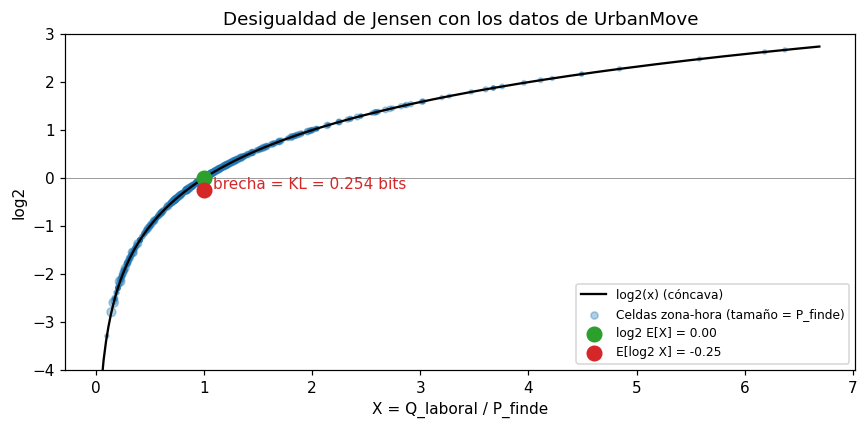

In [17]:
# Visualización: la brecha de Jensen con los valores reales X = Q/P
x_graf = np.linspace(0.05, X.max() * 1.05, 300)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_graf, np.log2(x_graf), color='k', lw=1.5, label='log2(x) (cóncava)')
ax.scatter(X, np.log2(X), s=6 + 3000 * P_c, alpha=0.35, color='C0',
           label='Celdas zona-hora (tamaño = P_finde)')
ax.scatter([1], [log_EX], color='C2', s=90, zorder=5, label=f'log2 E[X] = {log_EX:.2f}')
ax.scatter([1], [E_logX], color='C3', s=90, zorder=5, label=f'E[log2 X] = {E_logX:.2f}')
ax.annotate('', xy=(1, E_logX), xytext=(1, log_EX), arrowprops=dict(arrowstyle='<->', color='C3'))
ax.text(1.08, (E_logX + log_EX) / 2, f'brecha = KL = {KL_PQ:.3f} bits', color='C3', va='center')
ax.axhline(0, color='gray', lw=0.5)
ax.set(xlabel='X = Q_laboral / P_finde', ylabel='log2', title='Desigualdad de Jensen con los datos de UrbanMove',
       ylim=(-4, 3))
ax.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

**Lectura:** Las tres verificaciones se cumplen exactamente con los datos propios: la brecha de Jensen es 0.2545 bits, idéntica a la KL de la sección 6; la información mutua hora–destino coincide con la KL entre la conjunta y el producto de marginales (0.0717 bits); y la entropía de la zona es $4.3219 - 0.3295 = 3.9924$ bits. Ese 0.33 bits es la distancia entre la demanda real y una demanda uniforme: es la estructura espacial que UrbanMove puede explotar. Como la curva es cóncava y los puntos $X = Q/P$ se agrupan cerca de 1, la brecha es pequeña, lo que coincide con que los dos contextos se parecen bastante en el espacio.

## 8. Log-sum-exp: combinar cientos de probabilidades sin perder precisión

**Problema operativo:** Dado el conjunto de viajes de un día (zona y hora de cada uno), ¿puede el sistema reconocer si ese día se comporta como laboral o como fin de semana? Esto importa porque los festivos y días atípicos no están marcados en el calendario de despacho.

**Modelo:** Dos contextos $k \in \{\text{laboral}, \text{finde}\}$, cada uno con su distribución sobre las 480 celdas zona × hora, $\theta_k$, y una probabilidad previa $\pi_k$ (la proporción de días de cada tipo). Para un día con viajes $x_1, \dots, x_n$, por el teorema de Bayes:

$$P(k \mid \text{día}) = \frac{\pi_k \prod_{i=1}^n \theta_k(x_i)}{\sum_{j} \pi_j \prod_{i=1}^n \theta_j(x_i)}$$

**El problema numérico:** Cada $\theta_k(x_i)$ es del orden de $1/480$, y un día tiene unos 275 viajes. El producto es del orden de $10^{-700}$, pero el número positivo más pequeño que representa un `float64` es de unos $10^{-308}$. El computador lo redondea a cero y el cociente queda $0/0$.

**La solución:** Se trabaja con logaritmos, $a_k = \log \pi_k + \sum_i \log\theta_k(x_i)$, y se usa la identidad

$$\log\sum_k e^{a_k} = m + \log\sum_k e^{a_k - m}, \qquad m = \max_k a_k$$

Al restar el máximo, el exponente más grande queda en $e^0 = 1$ y ninguno se desborda. Es algebraicamente exacto: solo se multiplica y divide por $e^{m}$.

Para no evaluar un día con un modelo que ya lo vio, $\theta_k$ se estima dejando fuera el día evaluado (validación dejando uno fuera).

In [18]:
def lse(a):
    """Log-sum-exp estable (logaritmo natural)."""
    a = np.asarray(a, float)
    m = a.max()
    return m + np.log(np.sum(np.exp(a - m)))

# Demostración con un día concreto
muestra['celda'] = celdas(muestra)
conteo_ctx = {k: np.bincount(muestra.loc[muestra.fin_de_semana == k, 'celda'], minlength=K * 24) for k in (0, 1)}
dias = muestra.groupby('fecha').agg(fin_de_semana=('fin_de_semana', 'first'), viajes=('id', 'size'))
pi = dias.fin_de_semana.value_counts(normalize=True).sort_index().values   # previa: proporción de días

def log_posterior_dia(fecha):
    viajes_dia = muestra.loc[muestra.fecha == fecha, 'celda'].values
    conteo_dia = np.bincount(viajes_dia, minlength=K * 24)
    a = np.zeros(2)
    for k in (0, 1):
        c = conteo_ctx[k] - (conteo_dia if dias.loc[fecha, 'fin_de_semana'] == k else 0)  # deja el día fuera
        log_theta = np.log((c + ALFA) / (c + ALFA).sum())
        a[k] = np.log(pi[k]) + log_theta[viajes_dia].sum()
    return a

fecha_ej = dias.index[dias.fin_de_semana == 0][10]
a = log_posterior_dia(fecha_ej)
print(f'Día de ejemplo: {fecha_ej.date()} ({dias.loc[fecha_ej, "viajes"]} viajes)')
print(f'a_laboral = {a[0]:.2f}   a_finde = {a[1]:.2f}   (logaritmo natural)')
with np.errstate(all='ignore'):
    ingenuo = np.exp(a) / np.exp(a).sum()
print(f'\nCálculo ingenuo:  exp(a) = {np.exp(a)}  ->  posterior = {ingenuo}')
post = np.exp(a - lse(a))
print(f'Con log-sum-exp:  LSE(a) = {lse(a):.2f}  ->  P(laboral) = {post[0]:.6f}, P(finde) = {post[1]:.2e}')
print(f'Verificación con scipy.special.logsumexp: {logsumexp(a):.2f}')

Día de ejemplo: 2016-01-15 (304 viajes)
a_laboral = -1756.70   a_finde = -1794.93   (logaritmo natural)

Cálculo ingenuo:  exp(a) = [0. 0.]  ->  posterior = [nan nan]
Con log-sum-exp:  LSE(a) = -1756.70  ->  P(laboral) = 1.000000, P(finde) = 2.50e-17
Verificación con scipy.special.logsumexp: -1756.70


In [19]:
# Aplicación a los 182 días del semestre
res = pd.DataFrame([log_posterior_dia(f) for f in dias.index], index=dias.index, columns=['a_laboral', 'a_finde'])
res['P(finde | viajes)'] = np.exp(res.a_finde - res.apply(lambda r: lse([r.a_laboral, r.a_finde]), axis=1))
res = res.join(dias)
res['predicho_finde'] = (res['P(finde | viajes)'] > 0.5).astype(int)
res['dia_semana'] = res.index.day_name()

acierto = (res.predicho_finde == res.fin_de_semana).mean()
print(f'Días clasificados correctamente: {100*acierto:.1f} % de {len(res)}')
display(pd.crosstab(res.fin_de_semana.map({0: 'Laboral real', 1: 'Finde real'}),
                    res.predicho_finde.map({0: 'Predicho laboral', 1: 'Predicho finde'})))
print('Días que el modelo clasifica distinto al calendario:')
res.loc[res.predicho_finde != res.fin_de_semana,
        ['dia_semana', 'viajes', 'P(finde | viajes)']].sort_index()

Días clasificados correctamente: 97.8 % de 182


predicho_finde,Predicho finde,Predicho laboral
fin_de_semana,,
Finde real,51,1
Laboral real,3,127


Días que el modelo clasifica distinto al calendario:


,dia_semana,viajes,P(finde | viajes)
fecha,,,
2016-01-01,Friday,259,1.0000
2016-01-24,Sunday,106,0.0007
2016-02-15,Monday,253,0.9999
2016-05-30,Monday,178,0.5021


**Lectura:** Con 304 viajes, el log de la probabilidad del día es −1757 (en logaritmo natural), así que $e^{-1757} \approx 10^{-763}$ está muy por debajo del mínimo de un `float64`: el cálculo ingenuo da 0/0 = NaN. El log-sum-exp da la respuesta correcta y coincide con `scipy`.

Con eso, el modelo reconoce el tipo de día en el **97.8 % de los 182 días** solo mirando dónde y a qué hora se pidieron los viajes. Los errores son más informativos que los aciertos:

- **1 de enero** (Año Nuevo, viernes) y **15 de febrero** (Día de los Presidentes, lunes): el modelo los ve como fin de semana con probabilidad ≈ 1. Son festivos, así que el modelo tiene razón y el calendario no.
- **30 de mayo** (Memorial Day, lunes): queda en 0.50, un día mixto.
- **24 de enero** (domingo): lo ve como laboral. Es el día siguiente a la gran tormenta de nieve de enero de 2016; el 23 de enero la muestra tiene solo 51 viajes y el 24 solo 106, un comportamiento atípico.

**Implicación:** UrbanMove no debería activar su plan de fin de semana por calendario sino por el patrón observado de demanda, que detecta festivos y días atípicos.

**Puente con el Rol 3:** la probabilidad $P(k \mid \text{día})$ es exactamente la *responsabilidad* del paso E del algoritmo EM, con dos componentes categóricas en vez de gaussianas. El log-sum-exp es la forma de calcularla sin desbordamiento.

## 9. Tabla de resultados del Rol 1 (para el documento PDF)

In [20]:
resumen = pd.DataFrame([
    ('Entropía', 'H(zona origen) global', f'{H_global:.3f} bits ({2**H_global:.1f} zonas efectivas de 20)'),
    ('Entropía', 'H(zona) franja más concentrada',
        f'{entropia_franja["H (bits)"].min():.3f} bits ({entropia_franja["H (bits)"].idxmin()})'),
    ('Entropía', 'H(zona) franja más dispersa',
        f'{entropia_franja["H (bits)"].max():.3f} bits ({entropia_franja["H (bits)"].idxmax()})'),
    ('Entropía condicional', 'H(destino | origen)',
        f'{condicionales.loc["X = zona de origen"].iloc[0]:.3f} bits (vs. {H_dest:.3f} sin información)'),
    ('Información mutua', 'I(zona origen; destino)', f'{im_tabla.iloc[3, 0]:.3f} bits'),
    ('Información mutua', 'I(hora; destino)', f'{obs:.4f} bits (azar: {nulas.mean():.4f}; p < {p_val:.3f})'),
    ('KL', 'KL(finde || laboral), hora', f'{kl_tabla.loc["hora del día", "KL(finde || laboral)"]:.3f} bits'),
    ('KL', 'KL(finde || laboral), zona', f'{kl_tabla.loc["zona de origen", "KL(finde || laboral)"]:.3f} bits'),
    ('KL', 'Hora más distinta del mapa promedio', f'{orden_kl.index[0]}:00 ({orden_kl.iloc[0]:.3f} bits)'),
    ('Entropía cruzada', 'H(P_finde, Q_laboral), zona×hora', f'{H_PQ:.3f} bits vs. H(P_finde) = {H_P:.3f}'),
    ('Jensen', 'Brecha E[log X] vs. log E[X]', f'{log_EX - E_logX:.3f} bits = KL'),
    ('Log-sum-exp', 'Clasificación de días por sus viajes', f'{100*acierto:.1f} % de 182 días'),
], columns=['Concepto', 'Medida', 'Valor'])
resumen.to_csv(f'{RUTA_DATOS}/resultados_rol1.csv', index=False)
resumen

,Concepto,Medida,Valor
0,Entropía,H(zona origen) global,3.992 bits (15.9 zonas efectivas de 20)
1,Entropía,H(zona) franja más concentrada,3.869 bits (madrugada)
2,Entropía,H(zona) franja más dispersa,3.968 bits (pico_am)
3,Entropía condicional,H(destino | origen),3.753 bits (vs. 4.130 sin información)
4,Información mutua,I(zona origen; destino),0.377 bits
5,Información mutua,I(hora; destino),0.0717 bits (azar: 0.0063; p < 0.002)
6,KL,"KL(finde || laboral), hora",0.188 bits
7,KL,"KL(finde || laboral), zona",0.050 bits
8,KL,Hora más distinta del mapa promedio,3:00 (0.471 bits)
9,Entropía cruzada,"H(P_finde, Q_laboral), zona×hora",8.669 bits vs. H(P_finde) = 8.415
